In [1]:
import numpy as np
import pandas as pd
import pickle
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import sem, ttest_1samp
import statsmodels.stats.multitest as multi

In [2]:
def to_day(di):
    if di >= 2:
        return "day6"
    else:
        return "day" + str(di + 1)

In [3]:
x = []
for mi in range(6):
    mouse = "mouse" + str(mi + 1)
    xs = []
    for di in range(3):
        day = to_day(di)
        xs.append(pd.read_csv("{0}/{0}_{1}.csv".format(mouse, day)).values)
    x.append(xs)

mouse1 day1
slope=0.589, R^2=0.886, p=0.000
corrcoef=0.94
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


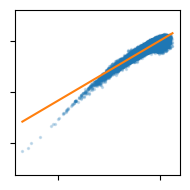

mouse1 day2
slope=0.547, R^2=0.830, p=0.000
corrcoef=0.91
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


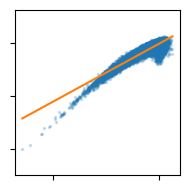

mouse1 day6
slope=0.551, R^2=0.847, p=0.000
corrcoef=0.92
X ticks=[-10.0, -5.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


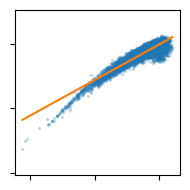

mouse2 day1
slope=0.640, R^2=0.879, p=0.000
corrcoef=0.94
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


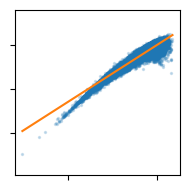

mouse2 day2
slope=0.647, R^2=0.879, p=0.000
corrcoef=0.94
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


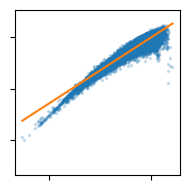

mouse2 day6
slope=0.657, R^2=0.922, p=0.000
corrcoef=0.96
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


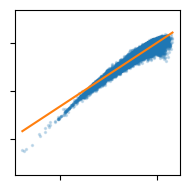

mouse3 day1
slope=0.617, R^2=0.776, p=0.000
corrcoef=0.88
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


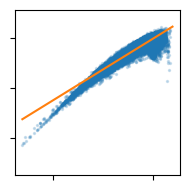

mouse3 day2
slope=0.622, R^2=0.772, p=0.000
corrcoef=0.88
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


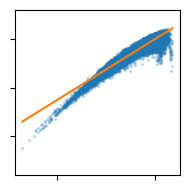

mouse3 day6
slope=0.650, R^2=0.918, p=0.000
corrcoef=0.96
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


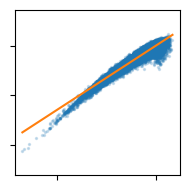

mouse4 day1
slope=0.620, R^2=0.792, p=0.000
corrcoef=0.89
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


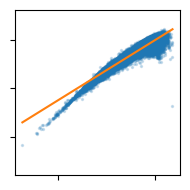

mouse4 day2
slope=0.633, R^2=0.856, p=0.000
corrcoef=0.93
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


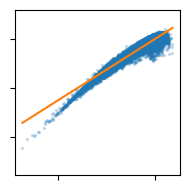

mouse4 day6
slope=0.643, R^2=0.909, p=0.000
corrcoef=0.95
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


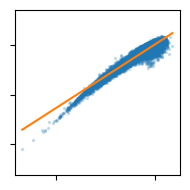

mouse5 day1
slope=0.610, R^2=0.896, p=0.000
corrcoef=0.95
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


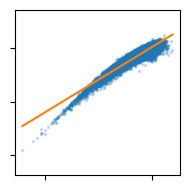

mouse5 day2
slope=0.602, R^2=0.856, p=0.000
corrcoef=0.92
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


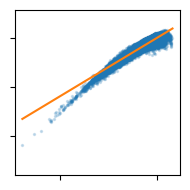

mouse5 day6
slope=0.607, R^2=0.901, p=0.000
corrcoef=0.95
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


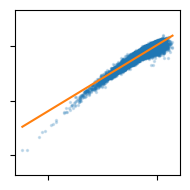

mouse6 day1
slope=0.601, R^2=0.880, p=0.000
corrcoef=0.94
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


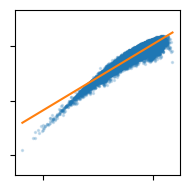

mouse6 day2
slope=0.599, R^2=0.871, p=0.000
corrcoef=0.93
X ticks=[-10.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


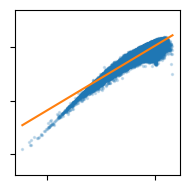

mouse6 day6
slope=0.617, R^2=0.881, p=0.000
corrcoef=0.94
X ticks=[-10.0, -5.0, 0.0]
Y ticks=[-10.0, -5.0, 0.0]


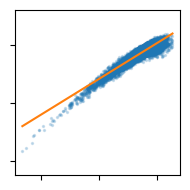

In [4]:
slopes = np.zeros((6, 3))
for mi in range(6):
    mouse = "mouse" + str(mi + 1)
    for di in range(3):
        day = to_day(di)
        mu = np.array([x[mi][di][i*300:(i+1)*300, :].mean(axis=0) for i in range(x[mi][di].shape[0]//300)]).reshape(-1)
        sigma = np.array([x[mi][di][i*300:(i+1)*300, :].std(axis=0) for i in range(x[mi][di].shape[0]//300)]).reshape(-1)
        log_mu = np.log(mu[(mu > 0) & (sigma > 0)])
        log_sigma = np.log(sigma[(mu > 0) & (sigma > 0)])
        slope, ic, r, p, _ = stats.linregress(log_mu, log_sigma)
        xmin, xmax = log_mu.min(), log_mu.max()
        ymin, ymax = max(log_sigma.min(), -12), log_sigma.max()
        half_width = max(xmax - xmin, ymax - ymin) / 2 * 1.1
        x_center = (xmax + xmin) / 2
        y_center = (ymax + ymin) / 2
        fig = plt.figure(figsize=(2, 2))
        ax = fig.add_subplot(111)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim([x_center - half_width, x_center + half_width])
        ax.set_ylim([y_center - half_width, y_center + half_width])
        ax.scatter(log_mu, log_sigma, s=2, alpha=0.2)
        ax.plot([xmin, xmax], [slope * xmin + ic, slope * xmax + ic], c="C1")
        ymin, ymax = plt.ylim()
        plt.tick_params(labelleft=False, labelbottom=False)
        plt.tight_layout()
        plt.savefig("figures/figs1/figs1_{}_{}.png".format(mouse, day))
        slopes[mi, di] = slope
        print(mouse, day)
        print("slope={:.3f}, R^2={:.3f}, p={:.3f}".format(slope, r**2, p))
        print("corrcoef={:.2f}".format(np.corrcoef(log_mu, log_sigma)[0, 1]))
        print("X ticks={}".format(list(plt.xticks()[0][1:-1])))
        print("Y ticks={}".format(list(plt.yticks()[0][1:-1])))
        plt.show()

one sample t-test with bonferroni correction
Day1: p=0.000 | Day2: p=0.000 | Day6: p=0.000


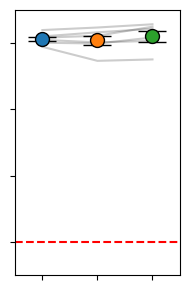

In [5]:
plt.figure(figsize=(2, 3))
plt.plot(slopes.T, color="k", alpha=0.2)
for di in range(3):
    plt.errorbar(x=di, y=slopes[:, di].mean(), yerr=sem(slopes[:, di]), fmt="o", ecolor="k", markeredgecolor="k", color="C"+str(di), capsize=10, markersize=10)
plt.xlim(-0.5, 2.5)
plt.ylim(-0.1, 0.7)
plt.yticks([0, 0.2, 0.4, 0.6])
plt.tick_params(labelbottom=False, labelleft=False)
plt.hlines(y=0, xmin=-0.5, xmax=2.5, color="r", linestyle="--")
plt.tight_layout()
plt.savefig("figures/figs1/figs1b.png")
p = multi.multipletests([ttest_1samp(slopes[:, di], 0).pvalue for di in range(3)], alpha=0.001, method="bonferroni")[1]
print("one sample t-test with bonferroni correction")
print("Day1: p={:.3f} | Day2: p={:.3f} | Day6: p={:.3f}".format(p[0], p[1], p[2]))